[Scan] Group=mask, directory=/home/dslabra5/sae4dlm/autointerp_hf/dream_mask_sae_interp_results, entries=36
[Scan] Finished group=mask: parsed_rows=36, skipped_files_without_meta=0
[Scan]   mask: non-ckpt=30, ckpt=6
[Scan]   mask: score_source counts:
score_source
per_latent_results    30
latents                6
Name: count, dtype: int64
[Scan] Group=unmask, directory=/home/dslabra5/sae4dlm/autointerp_hf/dream_unmask_sae_interp_results, entries=36
[Scan] Finished group=unmask: parsed_rows=36, skipped_files_without_meta=0
[Scan]   unmask: non-ckpt=34, ckpt=2
[Scan]   unmask: score_source counts:
score_source
per_latent_results    34
latents                2
Name: count, dtype: int64
[Scan] Group=llm, directory=/home/dslabra5/sae4dlm/autointerp_hf/llm_sae_interp_results, entries=36
[Scan] Finished group=llm: parsed_rows=36, skipped_files_without_meta=0
[Scan]   llm: non-ckpt=21, ckpt=15
[Scan]   llm: score_source counts:
score_source
per_latent_results    21
latents               15
Nam

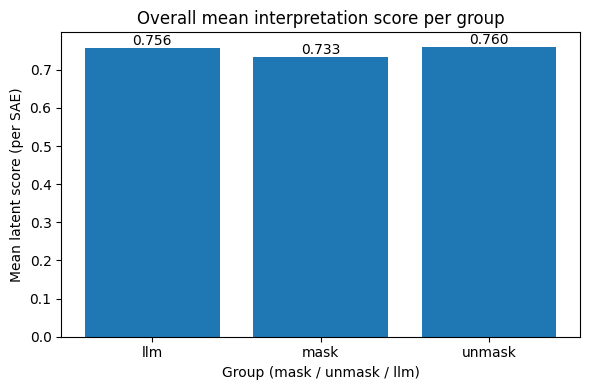

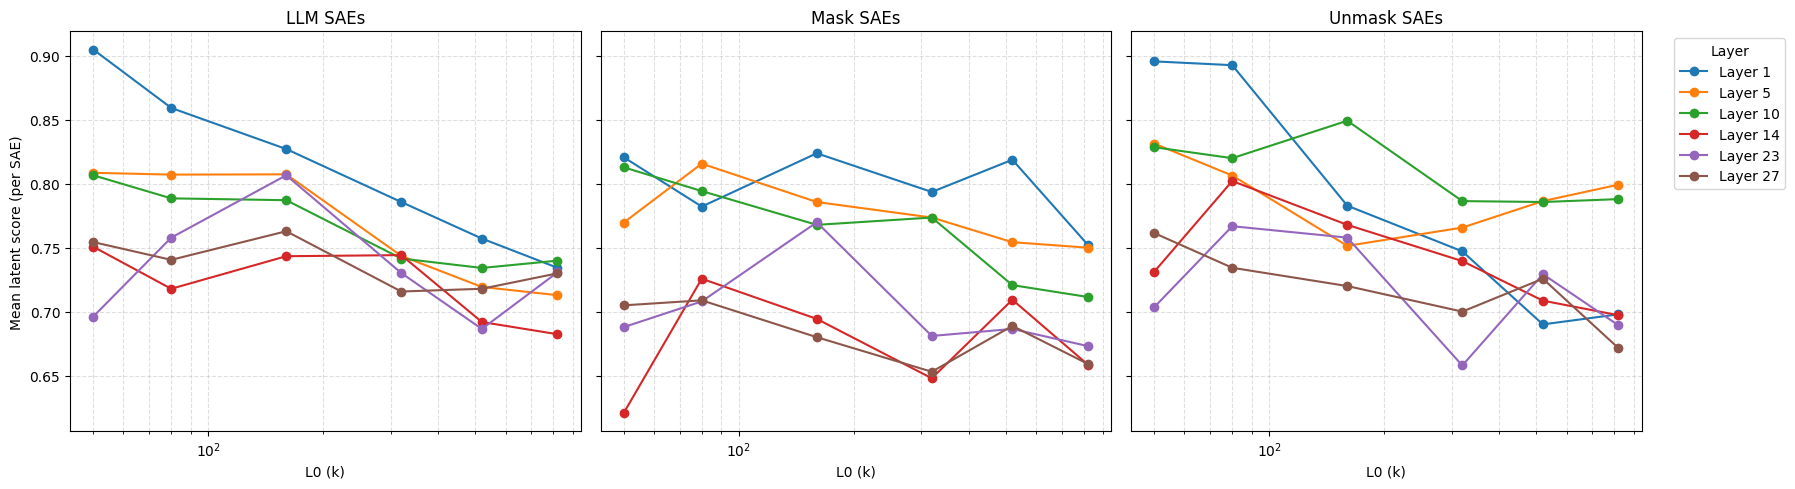

/tmp/ipykernel_3831620/2234498426.py:350: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups)


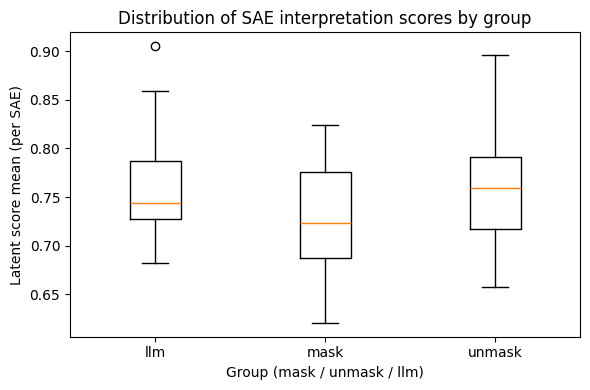

In [5]:
# -*- coding: utf-8 -*-

import os
import re
import json
from typing import Dict, Any, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- User parameters ----------------
# Directories containing autointerp JSON results.
MASK_DIR = "/home/dslabra5/sae4dlm/autointerp_hf/dream_mask_sae_interp_results"
UNMASK_DIR = "/home/dslabra5/sae4dlm/autointerp_hf/dream_unmask_sae_interp_results"
LLM_DIR = "/home/dslabra5/sae4dlm/autointerp_hf/llm_sae_interp_results"

# Path where the full table of results will be saved.
OUTPUT_CSV = "./dream_and_llm_sae_interp_scores.csv"

# Whether to show figures inside the notebook.
SHOW_FIGS = True


# ---------------- Filename parsing helpers ----------------
# We want to support filenames like:
#   dream_7b_layer23_l0_80.json
#   dream_7b_layer23_l0_80.ckpt.json
#   dream_7b_layer23_l0_80.json.ckpt.json
#   qwen2.5_7b_layer5_l0_160.json
#   qwen2.5_7b_layer5_l0_160.json.ckpt.json
#
# Approach:
#   1) Strip trailing extensions ".json" and ".ckpt" repeatedly.
#   2) Run a regex on the core name:  "<model_tag>_layer<layer>_l0_<k>"
CORE_NAME_RE = re.compile(r"(.+)_layer(\d+)_l0_(\d+)$")


def strip_ckpt_json_suffixes(filename: str) -> str:
    """
    Repeatedly strip trailing '.json' and '.ckpt' extensions from a filename,
    returning the remaining core name (without directory path).
    """
    name = filename
    while True:
        base, ext = os.path.splitext(name)
        ext_lower = ext.lower()
        if ext_lower in (".json", ".ckpt"):
            name = base
        else:
            break
    return name


def parse_meta_from_filename(filename: str) -> Optional[Tuple[str, int, int]]:
    """
    Parse (model_tag, layer, k) from a filename by:
      1) Stripping .json/.ckpt suffixes.
      2) Matching "<model_tag>_layer<layer>_l0_<k>" at the end.
    """
    core = strip_ckpt_json_suffixes(filename)
    m = CORE_NAME_RE.match(core)
    if not m:
        return None
    try:
        model_tag = m.group(1)
        layer = int(m.group(2))
        k = int(m.group(3))
        return model_tag, layer, k
    except Exception:
        return None


# ---------------- JSON helpers ----------------
def read_json_safe(path: str) -> Optional[Dict[str, Any]]:
    """Safely read a JSON file and return a dict, or None on failure."""
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print(f"[Warn] Failed to read JSON: {path} | {e}")
        return None


def safe_float(x: Any) -> Optional[float]:
    """Convert value to float, returning None if conversion fails."""
    try:
        return float(x)
    except Exception:
        return None


# ---------------- Data collection ----------------
def collect_interp_rows(root_dir: str, group_name: str) -> pd.DataFrame:
    """
    Collect interpretation results from all JSON-like files under root_dir.

    Each row corresponds to a single SAE (for a given model, layer and sparsity k)
    in the specified group ("mask", "unmask", or "llm").

    For each JSON we compute latent_score_mean using, in order of preference:
      1) per_latent_results[*]["score"]
      2) latents[*]["score"]
      3) metrics["autointerp_score"]  (fallback)
    """
    rows: List[Dict[str, Any]] = []
    if not os.path.isdir(root_dir):
        raise FileNotFoundError(f"Directory not found: {root_dir}")

    entries = sorted(os.listdir(root_dir))
    print(f"[Scan] Group={group_name}, directory={root_dir}, entries={len(entries)}")

    skipped = 0

    for fname in entries:
        path = os.path.join(root_dir, fname)
        # Skip directories or non-regular files
        if not os.path.isfile(path):
            continue

        # Only consider files that contain ".json" somewhere in their name
        if ".json" not in fname.lower():
            continue

        meta = parse_meta_from_filename(fname)
        if meta is None:
            skipped += 1
            print(f"[Skip] Could not parse model/layer/k from filename: {fname}")
            continue

        model_tag, layer, k = meta

        data = read_json_safe(path)
        if not data:
            # read_json_safe already printed a warning
            continue

        metrics = data.get("metrics", {})
        autointerp_score = safe_float(metrics.get("autointerp_score"))
        autointerp_std_dev = safe_float(metrics.get("autointerp_std_dev"))

        score_source = "none"
        latent_scores: List[float] = []

        # 1) Try per_latent_results
        per_latent = data.get("per_latent_results")
        if isinstance(per_latent, dict) and len(per_latent) > 0:
            for latent_id, latent_info in per_latent.items():
                s = safe_float(latent_info.get("score"))
                if s is not None:
                    latent_scores.append(s)
            score_source = "per_latent_results"

        # 2) If no per_latent_results, try latents
        if not latent_scores:
            latents = data.get("latents")
            if isinstance(latents, dict) and len(latents) > 0:
                for latent_id, latent_info in latents.items():
                    s = safe_float(latent_info.get("score"))
                    if s is not None:
                        latent_scores.append(s)
                score_source = "latents"

        # Now compute latent-based stats, or fallback to metrics
        n_latents = len(latent_scores)
        if n_latents > 0:
            latent_score_mean = float(np.mean(latent_scores))
            latent_score_sum = float(np.sum(latent_scores))
        elif autointerp_score is not None:
            # Fallback: no per-latent details, use aggregated autointerp_score
            latent_score_mean = autointerp_score
            latent_score_sum = autointerp_score
            score_source = "metrics"
        else:
            latent_score_mean = None
            latent_score_sum = None

        rows.append(
            {
                "group": group_name,           # "mask", "unmask", or "llm"
                "model_tag": model_tag,        # e.g. "dream_7b", "qwen2.5_7b"
                "file": path,
                "filename": fname,
                "layer": layer,
                "k": k,
                "autointerp_score": autointerp_score,
                "autointerp_std_dev": autointerp_std_dev,
                "latent_score_mean": latent_score_mean,
                "latent_score_sum": latent_score_sum,
                "n_latents": n_latents,
                "is_ckpt": ".ckpt" in fname.lower(),
                "score_source": score_source,
            }
        )

    df = pd.DataFrame(rows)
    print(
        f"[Scan] Finished group={group_name}: parsed_rows={len(df)}, "
        f"skipped_files_without_meta={skipped}"
    )
    if not df.empty:
        print(
            f"[Scan]   {group_name}: non-ckpt={len(df) - df['is_ckpt'].sum()}, "
            f"ckpt={df['is_ckpt'].sum()}"
        )
        print(
            f"[Scan]   {group_name}: score_source counts:\n"
            f"{df['score_source'].value_counts()}"
        )
    return df


# ---------------- Aggregation ----------------
def compute_overall_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute overall mean scores per group ("mask", "unmask", "llm").

    We use 'latent_score_mean' for each SAE:
      - If per-latent scores exist, this is the mean over latents.
      - If only 'latents' exists, it's the mean over those scores.
      - Otherwise, it's the fallback autointerp_score (if available).
    """
    use = df[df["latent_score_mean"].notnull()].copy()
    if use.empty:
        raise ValueError("No rows with usable scores found.")
    summary = (
        use.groupby("group")
        .agg(
            mean_latent_score=("latent_score_mean", "mean"),
            std_latent_score=("latent_score_mean", "std"),
            mean_autointerp_score=("autointerp_score", "mean"),
            std_autointerp_score=("autointerp_score", "std"),
            n_saes=("latent_score_mean", "size"),
            total_latents=("n_latents", "sum"),
        )
        .reset_index()
    )
    return summary


def compute_layer_k_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute per (group, model_tag, layer, k) stats, aggregating over multiple files
    (e.g. normal + ckpt) by taking the mean of latent_score_mean.
    """
    use = df[df["latent_score_mean"].notnull()].copy()
    if use.empty:
        return pd.DataFrame(
            columns=[
                "group",
                "model_tag",
                "layer",
                "k",
                "mean_latent_score",
                "std_latent_score",
                "mean_autointerp_score",
                "n_files",
            ]
        )
    g = (
        use.groupby(["group", "model_tag", "layer", "k"], dropna=True)
        .agg(
            mean_latent_score=("latent_score_mean", "mean"),
            std_latent_score=("latent_score_mean", "std"),
            mean_autointerp_score=("autointerp_score", "mean"),
            n_files=("latent_score_mean", "size"),
        )
        .reset_index()
    )
    return g.sort_values(["group", "model_tag", "layer", "k"])


# ---------------- Visualization helpers ----------------
def plot_overall_bar(summary: pd.DataFrame) -> None:
    """Bar plot of mean latent_score_mean per group."""
    fig, ax = plt.subplots(figsize=(6, 4))
    groups = summary["group"].tolist()
    means = summary["mean_latent_score"].tolist()
    ax.bar(groups, means)
    ax.set_xlabel("Group (mask / unmask / llm)")
    ax.set_ylabel("Mean latent score (per SAE)")
    ax.set_title("Overall mean interpretation score per group")
    for i, v in enumerate(means):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()


def plot_layer_k_lines(layer_k_stats: pd.DataFrame) -> None:
    """
    Line plots of mean latent score vs k for each layer and group.
    Different models in the same group are plotted together.
    """
    if layer_k_stats.empty:
        print("[Info] No layer/k stats to plot.")
        return

    groups = sorted(layer_k_stats["group"].dropna().unique())
    layers = sorted(layer_k_stats["layer"].dropna().unique())

    fig, axes = plt.subplots(
        1, len(groups), figsize=(6 * len(groups), 5), sharey=True
    )
    if len(groups) == 1:
        axes = [axes]

    for ax, group_name in zip(axes, groups):
        sub = layer_k_stats[layer_k_stats["group"] == group_name]
        for layer in layers:
            g = sub[sub["layer"] == layer].sort_values("k")
            if g.empty:
                continue
            ax.plot(
                g["k"].values,
                g["mean_latent_score"].values,
                marker="o",
                linestyle="-",
                label=f"Layer {layer}",
            )
        ax.set_xscale("log", base=10)
        ax.set_xlabel("L0 (k)")
        title_lookup = {
            "mask": "Mask SAEs",
            "unmask": "Unmask SAEs",
            "llm": "LLM SAEs",
        }
        ax.set_title(title_lookup.get(group_name, group_name.capitalize()))
        ax.grid(True, which="both", linestyle="--", alpha=0.4)

    axes[0].set_ylabel("Mean latent score (per SAE)")
    axes[-1].legend(title="Layer", bbox_to_anchor=(1.05, 1.0), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_score_distribution(df: pd.DataFrame) -> None:
    """Boxplot of latent_score_mean distribution by group."""
    use = df[df["latent_score_mean"].notnull()].copy()
    if use.empty:
        print("[Info] No data for boxplot.")
        return

    groups = sorted(use["group"].unique())
    data = [
        use[use["group"] == g]["latent_score_mean"].dropna().values
        for g in groups
    ]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot(data, labels=groups)
    ax.set_xlabel("Group (mask / unmask / llm)")
    ax.set_ylabel("Latent score mean (per SAE)")
    ax.set_title("Distribution of SAE interpretation scores by group")
    plt.tight_layout()
    plt.show()


# ---------------- Main ----------------
def main() -> None:
    # Collect data for all three groups
    df_mask = collect_interp_rows(MASK_DIR, "mask")
    df_unmask = collect_interp_rows(UNMASK_DIR, "unmask")
    df_llm = collect_interp_rows(LLM_DIR, "llm")

    df_all = pd.concat([df_mask, df_unmask, df_llm], ignore_index=True)
    print(f"[Info] Total SAEs collected: {len(df_all)}")
    print("\n[Info] SAEs per group (all files, including ckpt):")
    print(df_all["group"].value_counts())

    print("\n[Head of combined table]")
    print(df_all.head())

    # Save raw table to CSV so it is easy to inspect later
    df_all.to_csv(OUTPUT_CSV, index=False)
    print(f"\n[Info] Saved full table to: {OUTPUT_CSV}")

    # Overall stats: compare mask vs unmask vs llm
    summary = compute_overall_stats(df_all)
    print("\n=== Overall summary (per group) ===")
    print(summary.to_string(index=False))

    # Per (group, model_tag, layer, k) stats
    layer_k_stats = compute_layer_k_stats(df_all)
    print("\n=== Per (group, model_tag, layer, k) summary ===")
    print(layer_k_stats.to_string(index=False))

    # Visualizations
    if SHOW_FIGS:
        plot_overall_bar(summary)
        plot_layer_k_lines(layer_k_stats)
        plot_score_distribution(df_all)


if __name__ == "__main__":
    main()
